## Packages

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import pandas_datareader.data as web
from arch import arch_model

# R packages
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri, r, globalenv, default_converter
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.vectors import StrVector

base = importr('base')
methods = importr('methods')
rugarch = importr('rugarch')
rmgarch = importr('rmgarch')

### Data collection & initial visualization

Collect MSCI Europe Banks Index data

In [57]:
# Load the Excel file
df = pd.read_excel('msci_europe_banks.xlsx', engine='openpyxl')

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set the 'Date' column as the index
df.set_index('Date', inplace=True)

# Reverse the dataframe to have the most recent dates first
df = df.iloc[::-1]

# Display the first few rows of the dataframe
print(df.head())

            MSCI Europe Banks Index
Date                               
2025-09-29                99.179628
2025-09-26                99.587653
2025-09-25                97.867022
2025-09-24                99.091636
2025-09-23                99.421458


Collect stock prices from several banks

In [58]:
# Set the date range for the data import
start_date = datetime.datetime(1995, 2, 25)
end_date = datetime.datetime.today()

# Test other dates
# start_date = datetime.datetime(2002, 1, 1)
# end_date = datetime.datetime(2013, 12, 31)

# Fetch historical stock data from Yahoo Finance
ing_prices = web.DataReader("ING", "stooq", start_date, end_date)['Close']
db_prices = web.DataReader("DB", "stooq", start_date, end_date)['Close']
bbva_prices = web.DataReader("BBVA", "stooq", start_date, end_date)['Close']

# Display the first few rows of the data in three columns
data_preview = pd.concat([ing_prices.head(), db_prices.head(), bbva_prices.head()], axis=1)
data_preview.columns = ['ING Prices', 'Deutsche Bank Prices', 'BBVA Prices']
print(data_preview)

            ING Prices  Deutsche Bank Prices  BBVA Prices
Date                                                     
2025-10-08       24.44                 35.33        18.90
2025-10-07       24.48                 34.78        18.59
2025-10-06       25.32                 34.94        18.80
2025-10-03       25.78                 35.64        19.25
2025-10-02       25.80                 35.27        19.08


Visualize the data

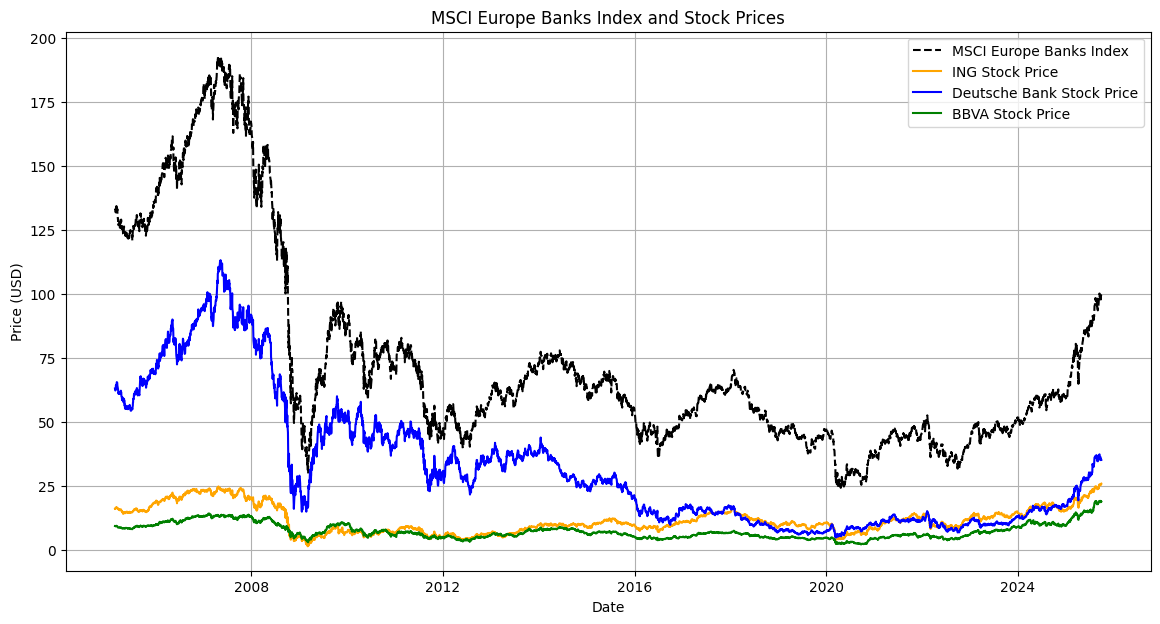

In [59]:
# Make sure all data are aligned by date
df = df.reindex(ing_prices.index).dropna()
ing_prices = ing_prices.reindex(df.index).dropna()
db_prices = db_prices.reindex(df.index).dropna()
bbva_prices = bbva_prices.reindex(df.index).dropna()

# Visualize the stock prices and market index
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['MSCI Europe Banks Index'], label='MSCI Europe Banks Index', color='black', linestyle='--')
plt.plot(ing_prices.index, ing_prices.values, label='ING Stock Price', color='orange')
plt.plot(db_prices.index, db_prices.values, label='Deutsche Bank Stock Price', color='blue')
plt.plot(bbva_prices.index, bbva_prices.values, label='BBVA Stock Price', color='green')
plt.title('MSCI Europe Banks Index and Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

### Preprocess data & returns visualization

In [60]:
# Calculate percentage log returns
msci_returns = 100 * np.log(df['MSCI Europe Banks Index'] / df['MSCI Europe Banks Index'].shift(1)).dropna()
ing_returns = 100 * np.log(ing_prices / ing_prices.shift(1)).dropna()
db_returns = 100 * np.log(db_prices / db_prices.shift(1)).dropna()
bbva_returns = 100 * np.log(bbva_prices / bbva_prices.shift(1)).dropna()

# Combine log returns into a single DataFrame
returns_df = pd.DataFrame({
    'MSCI Europe Banks Index': msci_returns,
    'ING': ing_returns,
    'Deutsche Bank': db_returns,
    'BBVA': bbva_returns,
}).dropna()

# Display the first few rows of the returns DataFrame
print("Log returns DataFrame:\n", returns_df.head())

Log returns DataFrame:
             MSCI Europe Banks Index       ING  Deutsche Bank      BBVA
Date                                                                  
2025-09-26                 0.410556 -0.230858       1.042410  1.149438
2025-09-25                -1.742855 -1.396454      -1.297620 -2.418625
2025-09-24                 1.243540  0.584228       2.051498  2.574348
2025-09-23                 0.332293 -0.155461       0.886187 -1.568250
2025-09-22                -0.771886 -1.095044       0.440166 -0.846566


Visualize log returns

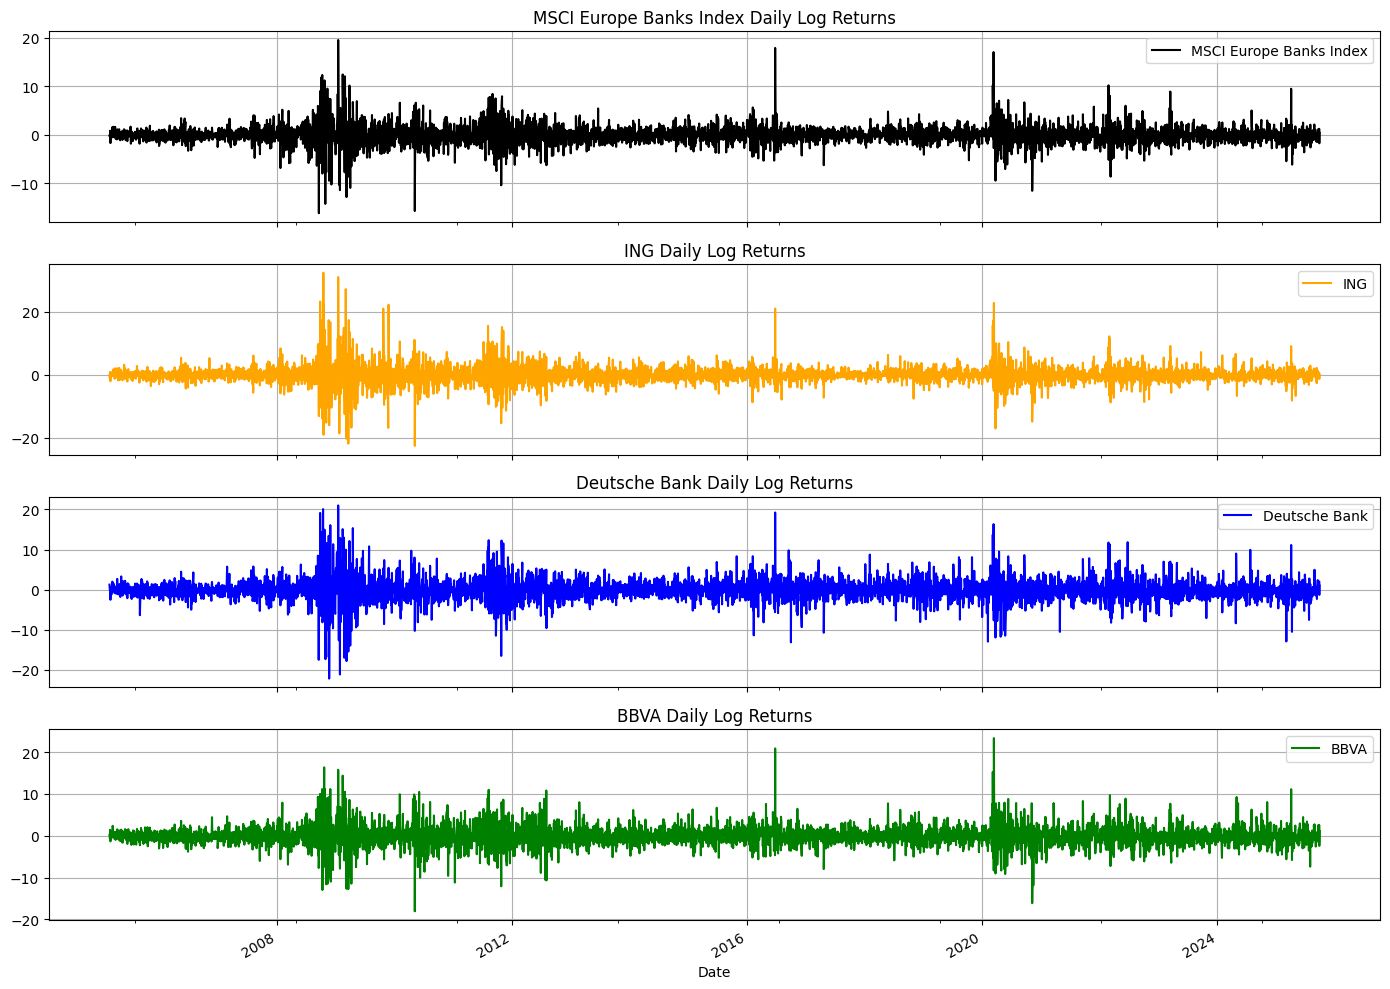

In [61]:
# Plot the log returns of the index and stocks
returns_df.plot(subplots=True, layout=(4, 1), figsize=(14, 10), color=['black', 'orange', 'blue', 'green'], title=['MSCI Europe Banks Index Daily Log Returns', 'ING Daily Log Returns', 'Deutsche Bank Daily Log Returns', 'BBVA Daily Log Returns'], legend=True, grid=True)
plt.tight_layout()
plt.show()


### Univariate GARCH(1,1) model fitting

Using the Python arch package

In [62]:
# Create an empty DataFrame to store conditional variances
cond_var_df = pd.DataFrame(index=returns_df.index, columns=returns_df.columns)

# Fit GARCH(1,1) model for each asset and store conditional variances
for asset in returns_df.columns:
    model = arch_model(returns_df[asset], vol='GARCH', p=1, q=1, mean='Constant', dist='normal')
    res = model.fit(disp='off')
    cond_var_df[asset] = res.conditional_volatility ** 2

print("Conditional variances (Python arch):\n", cond_var_df.head())

Conditional variances (Python arch):
             MSCI Europe Banks Index       ING  Deutsche Bank      BBVA
Date                                                                  
2025-09-26                 0.995181  1.364327       2.217136  2.633423
2025-09-25                 0.940013  1.286615       2.184609  2.568375
2025-09-24                 1.166398  1.426876       2.189741  2.899639
2025-09-23                 1.242717  1.391075       2.376065  3.302013
2025-09-22                 1.154207  1.307715       2.310614  3.255895


Using R rugarch package

In [63]:
# Fit GARCH(1,1) model using rugarch and store results
rugarch_models = {}
cond_var_r_df = pd.DataFrame(index=returns_df.index, columns=returns_df.columns)

for asset in returns_df.columns:
    with localconverter(ro.default_converter + pandas2ri.converter):
        returns_r = ro.conversion.py2rpy(returns_df[asset].dropna())
    spec = rugarch.ugarchspec(
        variance_model=ro.ListVector({'model': 'sGARCH', 'garchOrder': ro.IntVector([1, 1]), 'variance.targeting': False}),
        mean_model=ro.ListVector({'armaOrder': ro.IntVector([0, 0]), 'include.mean': True}),
        distribution_model='norm'
    )
    fit = rugarch.ugarchfit(spec, returns_r, solver='hybrid')
    rugarch_models[asset] = fit
    cond_var_r_df.loc[returns_df[asset].dropna().index, asset] = np.array(rugarch.sigma(fit)).flatten()[::-1] ** 2

print("Conditional variances (R rugarch):\n", cond_var_r_df.head())


Conditional variances (R rugarch):
            MSCI Europe Banks Index       ING Deutsche Bank      BBVA
Date                                                                
2025-09-26                1.235462   1.71533      2.778869  3.080475
2025-09-25                1.027434  1.638373      2.812044  2.803729
2025-09-24                0.929341  1.713746      2.681074  2.394258
2025-09-23                0.984363  1.847918      2.761422  2.352286
2025-09-22                1.003397   1.87295       2.88596  2.460017


Compare the conditional variances from Python and R

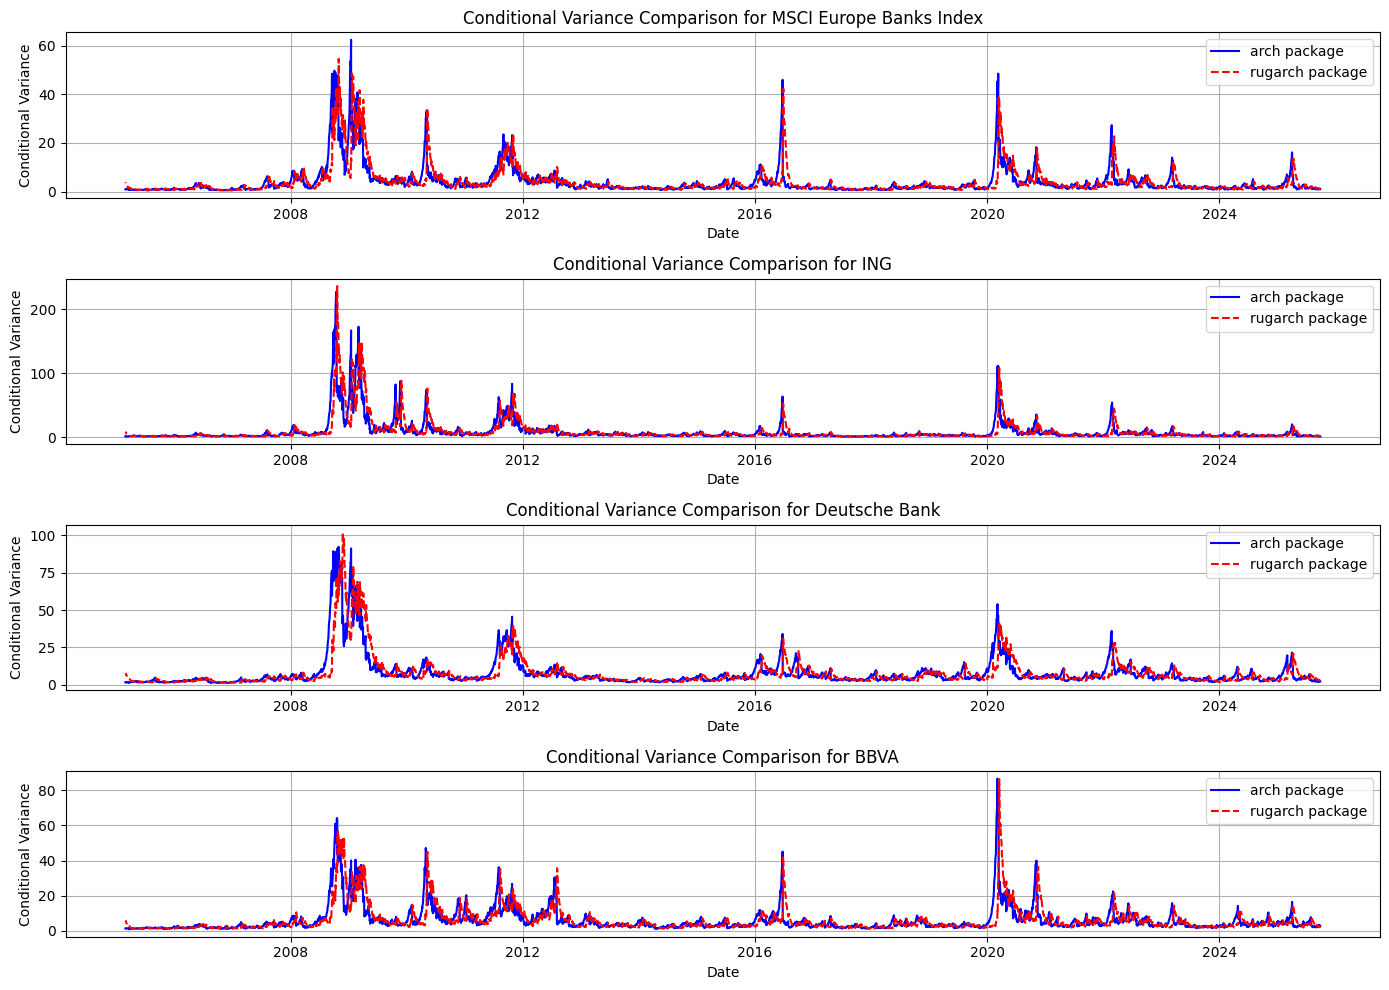

Correlation of conditional variances for MSCI Europe Banks Index: 0.6596
Correlation of conditional variances for ING: 0.6797
Correlation of conditional variances for Deutsche Bank: 0.7591
Correlation of conditional variances for BBVA: 0.5822


In [64]:
# Compare the conditional variances from arch and rugarch
plt.figure(figsize=(14, 10))
for i, asset in enumerate(returns_df.columns, 1):
    plt.subplot(4, 1, i)
    plt.plot(cond_var_df[asset], label='arch package', color='blue')
    plt.plot(cond_var_r_df[asset], label='rugarch package', color='red', linestyle='--')
    plt.title(f'Conditional Variance Comparison for {asset}')
    plt.xlabel('Date')
    plt.ylabel('Conditional Variance')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

# Compare how much the conditional variance correlate
for asset in returns_df.columns:
    corr = cond_var_df[asset].corr(cond_var_r_df[asset])
    print(f'Correlation of conditional variances for {asset}: {corr:.4f}')


Compute the diagonal matrix of conditional standard deviations $D_t = diag(\sqrt{h_{MSCI,t,}},\sqrt{h_{ING,t}},\sqrt{h_{DB,t}},\sqrt{h_{BBVA,t}})$

In [65]:
# Calculate D matrices and save diagonal elements to a CSV
# Ensure all columns in cond_var_r_df are numeric
cond_var_r_df = cond_var_r_df.apply(pd.to_numeric, errors='coerce')

# Calculate D matrices
D_matrices = {date: np.diag(np.sqrt(cond_var_r_df.loc[date])) for date in cond_var_r_df.index}

# Flatten D matrices into a DataFrame for CSV export
D_df = pd.DataFrame({
    'Date': cond_var_r_df.index,
    **{f'D_{i+1}{i+1}': [D_matrices[date][i, i] for date in cond_var_r_df.index] for i in range(4)}
}).set_index('Date')

# Save the D matrices to a CSV file
D_df.to_csv('D_matrices.csv')
print("D matrices saved to D_matrices.csv")
print("D Matrices DataFrame:\n", D_df.head())


D matrices saved to D_matrices.csv
D Matrices DataFrame:
                 D_11      D_22      D_33      D_44
Date                                              
2025-09-26  1.111513  1.309706  1.666994  1.755128
2025-09-25  1.013624  1.279989  1.676915  1.674434
2025-09-24  0.964024  1.309101  1.637399  1.547339
2025-09-23  0.992151  1.359382  1.661753  1.533716
2025-09-22  1.001697  1.368558  1.698811  1.568444


### DCC estimation

To compute the time-varying conditional correlation matrix we use the DCC approach introduced by Engle (2002)

In [66]:
# Convert your returns dataframe to R
with localconverter(ro.default_converter + pandas2ri.converter):
    returns_r = ro.conversion.py2rpy(returns_df.dropna())

# Define univariate GARCH specs for each asset using rugarch
uspec = rugarch.multispec([
    rugarch.ugarchspec(
        variance_model=ro.ListVector({'model': 'sGARCH', 'garchOrder': ro.IntVector([1, 1])}),
        mean_model=ro.ListVector({'armaOrder': ro.IntVector([0, 0]), 'include.mean': True}),
        distribution_model='norm'
    ) for _ in range(returns_df.shape[1])
])

# Define DCC spec
dcc_spec = rmgarch.dccspec(uspec=uspec, dccOrder=ro.IntVector([1, 1]), distribution='mvnorm')

# Fit the DCC model
dcc_fit = rmgarch.dccfit(dcc_spec, data=returns_r)

# Extract R_t matrices
Rt_array = rmgarch.rcor(dcc_fit)

# Convert the full 3D array from R to NumPy
with localconverter(default_converter + numpy2ri.converter):
    Rt_array_np = ro.conversion.rpy2py(Rt_array)

# Create a DataFrame to store the R matrices
R_matrices = {date: Rt_array_np[:, :, i] for i, date in enumerate(returns_df.index)}

# Flatten the R matrices into a DataFrame for CSV export
R_df = pd.DataFrame({
    'Date': returns_df.index,
    **{f'R_{row+1}{col+1}': [R_matrices[date][row, col] for date in returns_df.index] for row in range(Rt_array_np.shape[0]) for col in range(Rt_array_np.shape[1])}
}).set_index('Date')

# Save the R matrices to a CSV file
R_df.to_csv('R_matrices.csv')
print("R matrices saved to R_matrices.csv")
print("R Matrices DataFrame:\n", R_df.head().to_string())

R matrices saved to R_matrices.csv
R Matrices DataFrame:
             R_11      R_12      R_13      R_14      R_21  R_22      R_23      R_24      R_31      R_32  R_33      R_34      R_41      R_42      R_43  R_44
Date                                                                                                                                                      
2025-09-26   1.0  0.728537  0.692032  0.732191  0.728537   1.0  0.717839  0.740917  0.692032  0.717839   1.0  0.712221  0.732191  0.740917  0.712221   1.0
2025-09-25   1.0  0.728335  0.689101  0.731616  0.728335   1.0  0.715280  0.740477  0.689101  0.715280   1.0  0.711313  0.731616  0.740477  0.711313   1.0
2025-09-24   1.0  0.726852  0.688983  0.731133  0.726852   1.0  0.714525  0.740810  0.688983  0.714525   1.0  0.711176  0.731133  0.740810  0.711176   1.0
2025-09-23   1.0  0.727619  0.686132  0.733118  0.727619   1.0  0.713129  0.741101  0.686132  0.713129   1.0  0.706546  0.733118  0.741101  0.706546   1.0
2025-09-22  

Next, we compute the time-varying conditional covariance matrix $H_t$ decomposed as $H_t = D_t R_t D_t$.

In [67]:
# Compute matrices H_t = D_t * R_t * D_t and save to CSV
H_matrices = {}
for date in returns_df.index:
    D_t = D_matrices[date]
    R_t = R_matrices[date]
    H_t = D_t @ R_t @ D_t
    H_matrices[date] = H_t

# Flatten H matrices into a DataFrame for CSV export
H_df = pd.DataFrame({
    'Date': returns_df.index,
    **{f'H_{row+1}{col+1}': [H_matrices[date][row, col] for date in returns_df.index] for row in range(Rt_array_np.shape[0]) for col in range(Rt_array_np.shape[1])}
}).set_index('Date')

# Save the H matrices to a CSV file
H_df.to_csv('H_matrices.csv')
print("H matrices saved to H_matrices.csv")
print("H Matrices DataFrame:\n", H_df.head().to_string())

H matrices saved to H_matrices.csv
H Matrices DataFrame:
                 H_11      H_12      H_13      H_14      H_21      H_22      H_23      H_24      H_31      H_32      H_33      H_34      H_41      H_42      H_43      H_44
Date                                                                                                                                                                      
2025-09-26  1.235462  1.060572  1.282256  1.428394  1.060572  1.715330  1.567239  1.703147  1.282256  1.567239  2.778869  2.083809  1.428394  1.703147  2.083809  3.080475
2025-09-25  1.027434  0.944963  1.171307  1.241732  0.944963  1.638373  1.535302  1.587033  1.171307  1.535302  2.812044  1.997284  1.241732  1.587033  1.997284  2.803729
2025-09-24  0.929341  0.917291  1.087553  1.090611  0.917291  1.713746  1.531598  1.500603  1.087553  1.531598  2.681074  1.801843  1.090611  1.500603  1.801843  2.394258
2025-09-23  0.984363  0.981348  1.131232  1.115569  0.981348  1.847918  1.610927  1.545

### Time-varying Betas

The conditional beta of asset i with respect to the market at time t is defined as: $\beta_{i,t} = \frac{Cov_t(r_{i,t}, r_{m,t})}{Var_t(r_{m,t})} = \frac{h_{im,t}}{h_{m,t}}$ where $h_{im,t}$ is the (i, m)-th element of the conditional covariance matrix $H_t$.

In [68]:
# Initialize list to store H_t matrices
Ht_list = []
Ht_list = [H_df.loc[date].values.reshape(4, 4) for date in H_df.index]

# Compute conditional betas: beta_{i,t} = h_{im,t} / h_{m,t}
market_index = 0
bank_indices = [1, 2, 3]
bank_names = cond_var_r_df.columns[1:]

beta_df = pd.DataFrame(index=cond_var_r_df.index, columns=bank_names)

for t, H_t in enumerate(Ht_list):
    h_mm_t = H_t[market_index, market_index]
    for i, bank_idx in enumerate(bank_indices):
        h_im_t = H_t[bank_idx, market_index]
        beta_df.iloc[t, i] = h_im_t / h_mm_t if h_mm_t != 0 else np.nan

# Convert to float and display
beta_df = beta_df.astype(float)
print(beta_df.head())

# Save the beta values to a CSV file
beta_df.to_csv('conditional_betas.csv')
print("Conditional betas saved to conditional_betas.csv")


                 ING  Deutsche Bank      BBVA
Date                                         
2025-09-26  0.858441       1.037876  1.156162
2025-09-25  0.919731       1.140032  1.208577
2025-09-24  0.987033       1.170241  1.173531
2025-09-23  0.996937       1.149201  1.133290
2025-09-22  0.992632       1.162674  1.147637
Conditional betas saved to conditional_betas.csv


Plot the dynamic betas

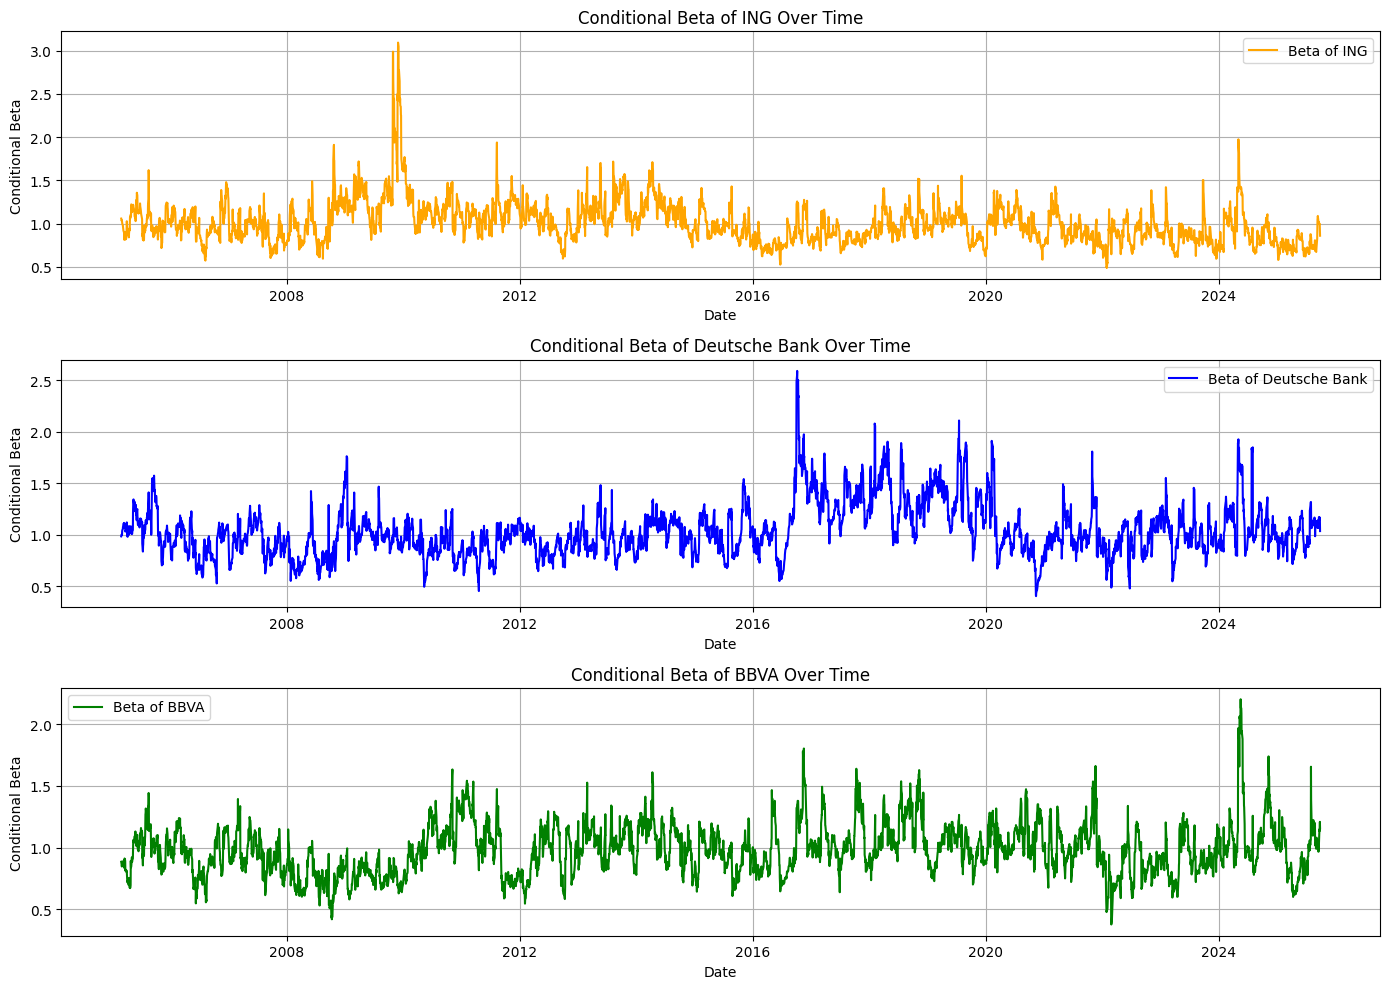

In [69]:
# Plot the conditional betas over time for the three banks
plt.figure(figsize=(14, 10))
for i, bank in enumerate(bank_names, 1):
    plt.subplot(3, 1, i)
    plt.plot(beta_df.index, beta_df[bank], label=f'Beta of {bank}', color=['orange', 'blue', 'green'][i-1])
    plt.title(f'Conditional Beta of {bank} Over Time')
    plt.xlabel('Date')
    plt.ylabel('Conditional Beta')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()